Steel demand

In [96]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.optimize import curve_fit
import pandas_datareader.wb as wb
import statsmodels.api as sm
from scipy import stats
from dynamic_stock_model import DynamicStockModel

Load data

In [97]:
# Load data

def load_files(filename):
    base_path = Path.cwd().parent
    historic_folder = base_path / "data" / "raw" / "Steel"
    
    file_path = historic_folder / filename
    df = pd.read_excel(file_path)
    
    return df

steel_file = "steel_demand.xlsx"

steel_data = load_files(steel_file)

Look at data

In [98]:
base_path = Path.cwd().parent
historic_gdp_data = pd.read_csv(base_path / "data" / "raw" / "gdp" / "gdp_1960_2024.csv")
future_gdp_data = pd.read_csv(base_path / "data" / "raw" / "gdp" / "gdp_1980_2100.csv")

# Create dataframe for the years 1960 to 2024 with the columns "year" and "gdp"
historic_gdp = pd.DataFrame({
    "year": np.arange(1960, 2025),
    "gdp": None
})

# Melt wide format to long format
historic_gdp_data_long = historic_gdp_data.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="year",
    value_name="gdp"
)

historic_gdp_data_long["year"] = historic_gdp_data_long["year"].astype(int)

# Then fill in the historic dataframe
for index, row in historic_gdp.iterrows():
    year = row["year"]
    match = historic_gdp_data_long.loc[historic_gdp_data_long["year"] == year, "gdp"]
    if not match.empty:
        historic_gdp.at[index, "gdp"] = match.values[0]

display(historic_gdp)

# Create dataframe for the years 2025 to 2050 with the columns "year", "SSP1", "SSP2", "SSP3" "SSP5"
future_gdp = pd.DataFrame({
    "year": np.arange(2025, 2051),
    "SSP1": None,
    "SSP2": None,
    "SSP3": None,
    "SSP5": None
})

# Fill the future_gdp dataframe with corresponding GDP values from future_gdp_data
# The data has scenario columns "SSP1", "SSP2", "SSP3" and "SSP5" and the value is in the corresponding every 5th year column (2025, 2030, ..., 2050)
# The unit column has the value "billion USD_2017/yr"
for index, row in future_gdp.iterrows():
    year = row["year"]
    if year % 5 != 0:
        continue
    for ssp in ["SSP1", "SSP2", "SSP3", "SSP5"]:
        gdp_value = future_gdp_data.loc[(future_gdp_data["scenario"] == ssp) & (future_gdp_data["unit"] == "billion USD_2015/yr"), str(year)].values[0]
        future_gdp.at[index, ssp] = gdp_value

for col in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    future_gdp[col] = pd.to_numeric(future_gdp[col], errors='coerce')
    future_gdp[col] = future_gdp[col] * 1e9

# Scale future GDP to match historic at join point
correction = historic_gdp.loc[historic_gdp['year'] == 2024, 'gdp'].values[0] / \
             future_gdp.loc[future_gdp['year'] == 2025, 'SSP2'].values[0]

print(f"Correction factor: {correction:.4f}")

for col in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    future_gdp[col] = future_gdp[col] * correction

display(future_gdp)

,year,gdp
0,1960,11069600000000.0
1,1961,11508300000000.0
2,1962,12121300000000.0
3,1963,12728300000000.0
4,1964,13567500000000.0
...,...,...
60,2020,82803300000000.0
61,2021,88113700000000.0
62,2022,91112300000000.0
63,2023,93798800000000.0


Correction factor: 0.6486


,year,SSP1,SSP2,SSP3,SSP5
0,2025,9.649255e+13,9.649270e+13,9.649268e+13,9.649269e+13
1,2026,NaN,NaN,NaN,NaN
2,2027,NaN,NaN,NaN,NaN
3,2028,NaN,NaN,NaN,NaN
4,2029,NaN,NaN,NaN,NaN
5,2030,1.127721e+14,1.125457e+14,1.122892e+14,1.130845e+14
6,2031,NaN,NaN,NaN,NaN
7,2032,NaN,NaN,NaN,NaN
8,2033,NaN,NaN,NaN,NaN
9,2034,NaN,NaN,NaN,NaN


Clean data

In [181]:
# New dataframe for steel production from 1980 to 2020
steel_1980 = steel_data[(steel_data["Year"] >= 1950) & (steel_data["Year"] < 2021)][["Year", "Steel", "GDP"]].copy()

# Add data for steel production from 2021 to 2024
steel_2021_2024 = pd.DataFrame({
    "Year": [2021, 2022, 2023, 2024],
    "Steel": [1963, 1889, 1904, 1885] # in Mt, from World Steel Association
})

# Combine steel_historic and steel_2021_2024 for a complete dataset from 1850 to 2024
steel_historic = pd.concat([steel_1980, steel_2021_2024], ignore_index=True)

# Ensure year columns are integers
steel_1980["Year"] = steel_1980["Year"].astype(int)
historic_gdp["year"] = historic_gdp["year"].astype(int)

# Merge GDP into steel_1980 by matching years
steel_historic = steel_historic.merge(
    historic_gdp[["year", "gdp"]],
    left_on="Year",       # your steel dataframe column
    right_on="year",      # GDP dataframe column
    how="left"
)

# Drop 'year' and 'GDP' columns from steel_historic if they exist
steel_historic = steel_historic.drop(columns=['year', 'GDP'], errors='ignore')

# Look at the complete dataset
display(steel_historic.head(20))

,Year,Steel,gdp
0,1950,189.0,NaN
1,1951,NaN,NaN
2,1952,NaN,NaN
3,1953,NaN,NaN
4,1954,NaN,NaN
5,1955,270.0,NaN
6,1956,NaN,NaN
7,1957,NaN,NaN
8,1958,NaN,NaN
9,1959,NaN,NaN


Check correlation between steel and GDP growth

In [100]:
# Focus on the period from 1995 to 2024 for correlation analysis
steel_historic_1995 = steel_historic[steel_historic["Year"] >= 1995].copy()

# Remove Nan values before log transformation
steel_historic_1995 = steel_historic_1995.dropna(subset=['Steel'])

# method 1: Calculate log-differences (log growth rates) for steel and GDP
steel_historic_1995['steel_log_growth'] = np.log(steel_historic_1995['Steel']).diff()
steel_historic_1995['gdp'] = steel_historic_1995['gdp'].map(float)
steel_historic_1995['gdp_log_growth'] = np.log(steel_historic_1995['gdp']).diff()

# Remove NaN values resulting from the diff() operation
steel_historic_1995 = steel_historic_1995.dropna(subset=['steel_log_growth', 'gdp_log_growth'])

# Calculate correlation between log growth rates
log_growth_corr = steel_historic_1995['steel_log_growth'].corr(steel_historic_1995['gdp_log_growth'])

# Method 2: pct_change (for comparison)
pct_corr = steel_historic_1995['Steel'].pct_change().corr(steel_historic_1995['gdp'].pct_change())

# Compare results from both methods
print(f"Log-diff correlation: {log_growth_corr:.4f}")
print(f"Pct change correlation: {pct_corr:.4f}")

# Calculate Pearson correlation coefficient and p-value for log growth rates
r, p_value = stats.pearsonr(steel_historic_1995['steel_log_growth'], steel_historic_1995['gdp_log_growth'])
print(f"Correlation: {r:.4f}")
print(f"P-value: {p_value:.10f}")
print(f"N observations: {len(steel_historic_1995)}")

# Perform leave-one-out analysis to check robustness of correlation
for i in range(len(steel_historic_1995)):
    mask = [j for j in range(len(steel_historic_1995)) if j != i]
    r_loo, _ = stats.pearsonr(steel_historic_1995.iloc[mask, 0], steel_historic_1995.iloc[mask, 1])
    year = steel_historic_1995.index[i]
    print(f"Drop {year}: r = {r_loo:.4f}")

# Average GDP and steel production over time
avg_gdp = steel_historic_1995["gdp"].mean()
avg_steel = steel_historic_1995["Steel"].mean()

# Find the constant average GDP per ton of steel produced
constant_avg = avg_gdp / avg_steel
print(constant_avg)

Log-diff correlation: 0.8094
Pct change correlation: 0.9065
Correlation: 0.8094
P-value: 0.0000829918
N observations: 17
Drop 50: r = 0.9519
Drop 55: r = 0.9585
Drop 60: r = 0.9643
Drop 61: r = 0.9675
Drop 62: r = 0.9665
Drop 63: r = 0.9697
Drop 64: r = 0.9680
Drop 65: r = 0.9655
Drop 66: r = 0.9665
Drop 67: r = 0.9653
Drop 68: r = 0.9660
Drop 69: r = 0.9657
Drop 70: r = 0.9642
Drop 71: r = 0.9642
Drop 72: r = 0.9655
Drop 73: r = 0.9673
Drop 74: r = 0.9748
46461068403.44509


Historic steel production from GDP

In [101]:
# Historic steel from historic GDP using average historic constant
steel_from_historic = historic_gdp.copy()

if 'year' in steel_from_historic.columns:
    steel_from_historic = steel_from_historic.set_index('year')
steel_from_historic['Steel'] = steel_from_historic['gdp'] / constant_avg

display(steel_from_historic)

,gdp,Steel
year,,
1960,11069600000000.0,238.255391
1961,11508300000000.0,247.697705
1962,12121300000000.0,260.891547
1963,12728300000000.0,273.956248
1964,13567500000000.0,292.018683
...,...,...
2020,82803300000000.0,1782.208263
2021,88113700000000.0,1896.506108
2022,91112300000000.0,1961.046165


Future steel production from future GDP and average constant

In [102]:
intensity = steel_historic_1995.copy()
intensity['intensity'] = intensity['gdp'] / intensity['Steel']

slope_int, intercept_int, r_int, p_int, se_int = stats.linregress(
    intensity['Year'].dropna(), 
    np.log(intensity['intensity'].dropna())
)

print(f"Intensity decline rate: {slope_int:.4f} per year")

Intensity decline rate: -0.0030 per year


In [103]:
# Anchor point
anchor_year = 2020
anchor_gdp = historic_gdp.loc[historic_gdp['year'] == anchor_year, 'gdp'].values[0]
anchor_steel = steel_historic_1995.loc[steel_historic_1995['Year'] == anchor_year, 'Steel'].values[0]

# Future steel from future GDP (with log-linear interpolation)
def interpolate_ssp_gdp(df, ssps=['SSP1', 'SSP2', 'SSP3', 'SSP5']):
    if 'year' in df.columns:
        df = df.set_index('year')
    
    full_index = range(df.index.min(), df.index.max() + 1)
    df_interp = df.reindex(full_index)
    
    for ssp in ssps:
        if ssp not in df.columns:
            print(f"Warning: {ssp} not found in dataframe, skipping")
            continue
        
        log_col = f'log_{ssp}'
        df_interp[log_col] = np.log(df_interp[ssp])
        df_interp[log_col] = df_interp[log_col].interpolate(method='linear')
        df_interp[f'{ssp}_interpolated'] = np.exp(df_interp[log_col])
        df_interp.drop(columns=[log_col], inplace=True)
    return df_interp

GDP_interp = interpolate_ssp_gdp(future_gdp)

steel_future = pd.DataFrame(index=GDP_interp.index)
for scenario in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    col = f'{scenario}_interpolated'
    if col in GDP_interp.columns:
        gdp = GDP_interp[col]
        intensity_factor = np.exp(-0.006 * (GDP_interp.index - anchor_year))
        steel_future[scenario] = (gdp / constant_avg) * intensity_factor

display(steel_future)

,SSP1,SSP2,SSP3,SSP5
year,,,,
2025,2015.467282,2015.470435,2015.469982,2015.470330
2026,2066.862526,2066.034435,2065.091311,2068.008785
2027,2119.568369,2117.866982,2115.934328,2121.916791
2028,2173.618232,2170.999901,2168.029111,2177.230049
2029,2229.046390,2225.465816,2221.406480,2233.985190
2030,2285.887988,2281.298168,2276.098012,2292.219801
2031,2343.269148,2331.271461,2317.262933,2360.525440
2032,2402.090710,2382.339451,2359.172351,2430.866512
2033,2462.388832,2434.526118,2401.839733,2503.303671


Plot historic and future steel production estimated from GDP

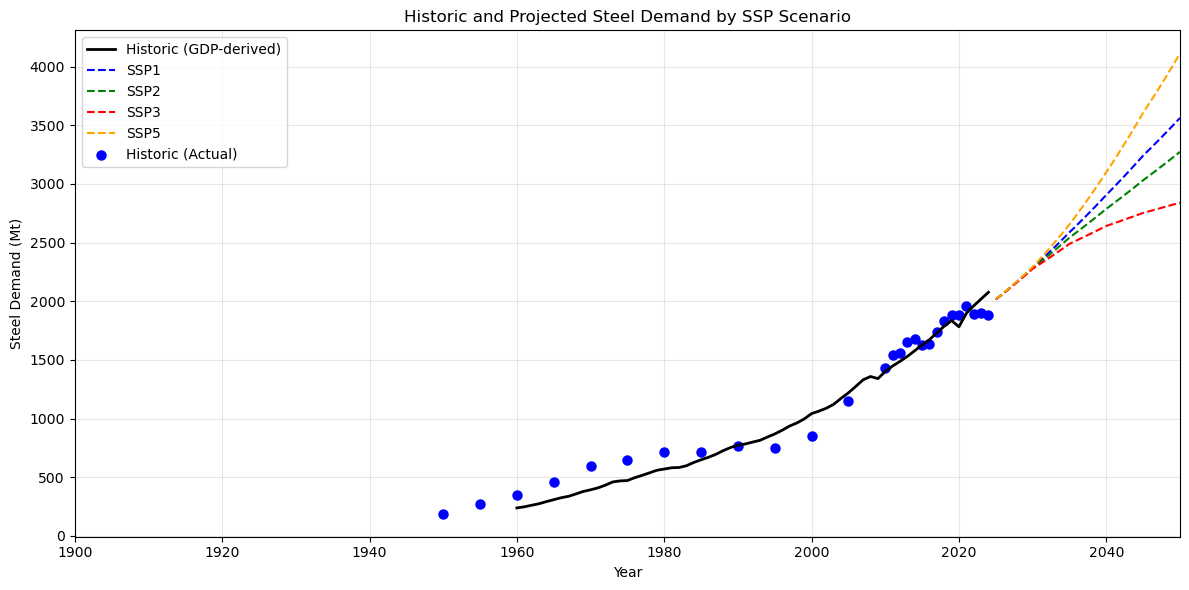

In [104]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot historic
ax.plot(steel_from_historic.index, steel_from_historic['Steel'], 
        color='black', linewidth=2, label='Historic (GDP-derived)', zorder=5)

# Plot future scenarios
colors = {'SSP1': 'blue', 'SSP2': 'green', 'SSP3': 'red', 'SSP5': 'orange'}
for scenario in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    col = f'{scenario}'
    if col in steel_future.columns:
        ax.plot(steel_future.index, steel_future[col],
                color=colors[scenario], linewidth=1.5, linestyle='--', label=scenario)

ax.scatter(steel_historic["Year"], steel_historic["Steel"],
        color='blue', linewidth=1.5, label='Historic (Actual)', zorder=4)

ax.set_xlabel('Year')
ax.set_ylabel('Steel Demand (Mt)')
ax.set_title('Historic and Projected Steel Demand by SSP Scenario')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2050)
plt.tight_layout()
plt.show()

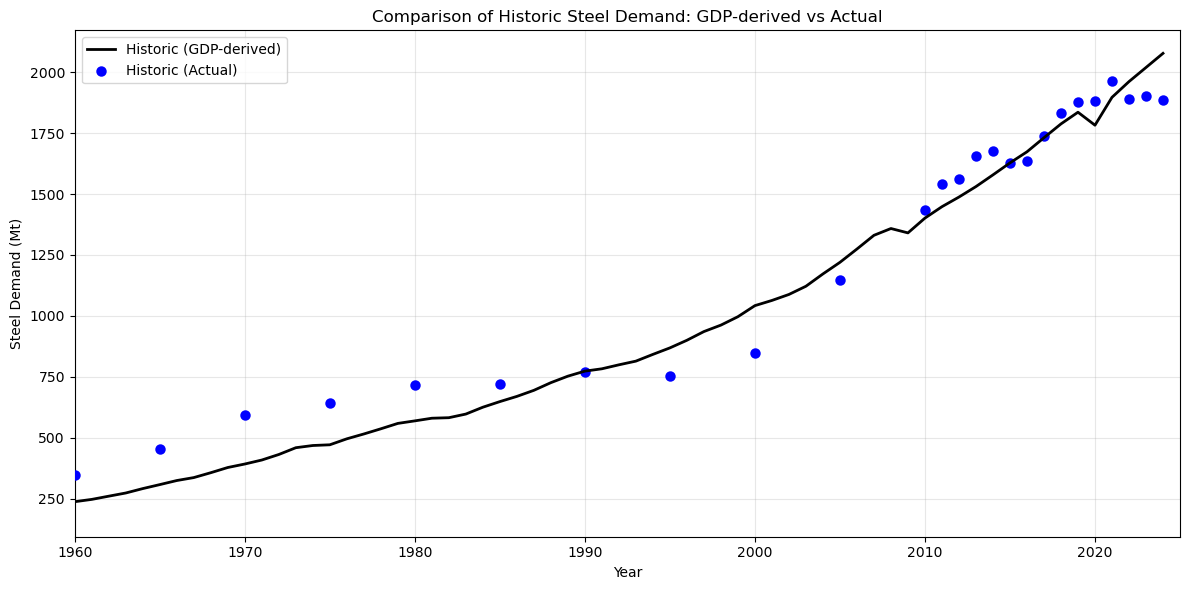

In [105]:
# Plot steel from steel_from_historic and steel from steel_historic
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(steel_from_historic.index, steel_from_historic['Steel'], 
        color='black', linewidth=2, label='Historic (GDP-derived)', zorder=5)
ax.scatter(steel_historic["Year"], steel_historic["Steel"],
        color='blue', linewidth=1.5, label='Historic (Actual)', zorder=4)
ax.set_xlabel('Year')
ax.set_ylabel('Steel Demand (Mt)')
ax.set_title('Comparison of Historic Steel Demand: GDP-derived vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1960, 2025)
plt.tight_layout()
plt.show()

In [251]:
# Get inflow data for steel production from 1960 to 2000 and 2000 to 2024 from steel_from_historic
# Create 1850-1949 with linear interpolation from 0 to first known value
first_value = steel_historic[steel_historic['Year'] == 1950]['Steel'].values[0]
steel_pre1950 = pd.DataFrame({
    'Year': range(1850, 1950),
    'Steel': np.linspace(0, first_value, 100)
}).set_index('Year')

# Combine with historic data
steel_historic_annual = steel_historic[['Year', 'Steel']].set_index('Year')
steel_historic_annual = pd.concat([steel_pre1950, steel_historic_annual])

# Reindex to every year and interpolate (for 5-year gaps after 1950)
steel_historic_annual = steel_historic_annual.reindex(range(1850, 2025)).interpolate(method='linear')

# Split into periods
steel_2000 = steel_historic_annual[steel_historic_annual.index <= 2000]['Steel'].astype(float).values
steel_2019 = steel_historic_annual[steel_historic_annual.index > 2000]['Steel'].astype(float).values

# Get future steel production from 2025 to 2050 per scenario
steel_ssp1 = steel_future['SSP1'].values

# Define timeframe for the combined historic and future data
t = np.arange(1850, 2025)

# Define shares for steel products (example values, can be adjusted)
shares_2000 = {
    "Buildings": 0.25,
    "Infrastructure - power": 0.0,
    "Infrastructure - transport and other": 0.13,
    "Vehicles": 0.13,
    "Mechanical and electrical equipment": 0.13,
    "Consumer goods, appliances and packaging": 0.13,
    "Pre-consumer scrap": 0.25
}

shares_2019 = {
    "Buildings": 0.26,
    "Infrastructure - power": 0.0,
    "Infrastructure - transport and other": 0.16,
    "Vehicles": 0.11,
    "Mechanical and electrical equipment": 0.16,
    "Consumer goods, appliances and packaging": 0.11,
    "Pre-consumer scrap": 0.21
}

# Define lifetime parameters for steel products
lt_buildings = {
    'Type': 'Normal',
    'Mean': np.full(len(t), 70),
    'StdDev': np.full(len(t), 25)
}

lt_infrastructure_power = {
    "Type": "Normal",
    "Mean": np.full(len(t), 45),
    "StdDev": np.full(len(t), 15)
}

lt_infrastructure_transport_other = {
    "Type": "Normal",
    "Mean": np.full(len(t), 50),
    "StdDev": np.full(len(t), 20)
}

lt_vehicles = {
    "Type": "Weibull",
    "Shape": np.full(len(t), 2.5),  # >1 = wear-out failure, typical for vehicles
    "Scale": np.full(len(t), 13.5)  # scale ≠ mean, needs conversion
}

lt_mechanical_electrical = {
    "Type": "Normal",
    "Mean": np.full(len(t), 20),
    "StdDev": np.full(len(t), 8)
}

lt_consumer_goods = {
    "Type": "Normal",
    "Mean": np.full(len(t), 8),
    "StdDev": np.full(len(t), 5)
}

# the pre consumer scrap is immediately an outflow
lt_pre_consumer_scrap = {
    "Type": "Normal",
    "Mean": np.full(len(t), 1),
    "StdDev": np.full(len(t), 0)
}


display(steel_2000)

array([  0.        ,   1.90909091,   3.81818182,   5.72727273,
         7.63636364,   9.54545455,  11.45454545,  13.36363636,
        15.27272727,  17.18181818,  19.09090909,  21.        ,
        22.90909091,  24.81818182,  26.72727273,  28.63636364,
        30.54545455,  32.45454545,  34.36363636,  36.27272727,
        38.18181818,  40.09090909,  42.        ,  43.90909091,
        45.81818182,  47.72727273,  49.63636364,  51.54545455,
        53.45454545,  55.36363636,  57.27272727,  59.18181818,
        61.09090909,  63.        ,  64.90909091,  66.81818182,
        68.72727273,  70.63636364,  72.54545455,  74.45454545,
        76.36363636,  78.27272727,  80.18181818,  82.09090909,
        84.        ,  85.90909091,  87.81818182,  89.72727273,
        91.63636364,  93.54545455,  95.45454545,  97.36363636,
        99.27272727, 101.18181818, 103.09090909, 105.        ,
       106.90909091, 108.81818182, 110.72727273, 112.63636364,
       114.54545455, 116.45454545, 118.36363636, 120.27

In [252]:
# Calculate inflows for each steel product category from 1960 to 2000
i_ssp1_buildings_2000 = steel_2000 * shares_2000["Buildings"]
i_ssp1_infrastructure_power_2000 = steel_2000 * shares_2000["Infrastructure - power"]
i_ssp1_infrastructure_transport_other_2000 = steel_2000 * shares_2000["Infrastructure - transport and other"]
i_ssp1_vehicles_2000 = steel_2000 * shares_2000["Vehicles"]
i_ssp1_mechanical_electrical_2000 = steel_2000 * shares_2000["Mechanical and electrical equipment"]
i_ssp1_consumer_goods_2000 = steel_2000 * shares_2000["Consumer goods, appliances and packaging"]
i_ssp1_pre_consumer_scrap_2000 = steel_2000 * shares_2000["Pre-consumer scrap"]

# Calculate inflows for each steel product category from 2001 to 2024
i_ssp1_buildings_2019 = steel_2019 * shares_2019["Buildings"]
i_ssp1_infrastructure_power_2019 = steel_2019 * shares_2019["Infrastructure - power"]
i_ssp1_infrastructure_transport_other_2019 = steel_2019 * shares_2019["Infrastructure - transport and other"]
i_ssp1_vehicles_2019 = steel_2019 * shares_2019["Vehicles"]
i_ssp1_mechanical_electrical_2019 = steel_2019 * shares_2019["Mechanical and electrical equipment"]
i_ssp1_consumer_goods_2019 = steel_2019 * shares_2019["Consumer goods, appliances and packaging"]
i_ssp1_pre_consumer_scrap_2019 = steel_2019 * shares_2019["Pre-consumer scrap"]

# Add together for the full period 1850 to 2024 (zero in the start because of weird outflow)
i_ssp1_buildings = np.concatenate([i_ssp1_buildings_2000, i_ssp1_buildings_2019])
i_ssp1_infrastructure_power = np.concatenate([i_ssp1_infrastructure_power_2000, i_ssp1_infrastructure_power_2019])
i_ssp1_infrastructure_transport_other = np.concatenate([i_ssp1_infrastructure_transport_other_2000, i_ssp1_infrastructure_transport_other_2019])
i_ssp1_vehicles = np.concatenate([i_ssp1_vehicles_2000, i_ssp1_vehicles_2019])
i_ssp1_mechanical_electrical = np.concatenate([i_ssp1_mechanical_electrical_2000, i_ssp1_mechanical_electrical_2019])
i_ssp1_consumer_goods = np.concatenate([i_ssp1_consumer_goods_2000, i_ssp1_consumer_goods_2019])
i_ssp1_pre_consumer_scrap = np.concatenate([i_ssp1_pre_consumer_scrap_2000, i_ssp1_pre_consumer_scrap_2019])

print(i_ssp1_buildings)

[0.00000000e+00 4.77272727e-01 9.54545455e-01 1.43181818e+00
 1.90909091e+00 2.38636364e+00 2.86363636e+00 3.34090909e+00
 3.81818182e+00 4.29545455e+00 4.77272727e+00 5.25000000e+00
 5.72727273e+00 6.20454545e+00 6.68181818e+00 7.15909091e+00
 7.63636364e+00 8.11363636e+00 8.59090909e+00 9.06818182e+00
 9.54545455e+00 1.00227273e+01 1.05000000e+01 1.09772727e+01
 1.14545455e+01 1.19318182e+01 1.24090909e+01 1.28863636e+01
 1.33636364e+01 1.38409091e+01 1.43181818e+01 1.47954545e+01
 1.52727273e+01 1.57500000e+01 1.62272727e+01 1.67045455e+01
 1.71818182e+01 1.76590909e+01 1.81363636e+01 1.86136364e+01
 1.90909091e+01 1.95681818e+01 2.00454545e+01 2.05227273e+01
 2.10000000e+01 2.14772727e+01 2.19545455e+01 2.24318182e+01
 2.29090909e+01 2.33863636e+01 2.38636364e+01 2.43409091e+01
 2.48181818e+01 2.52954545e+01 2.57727273e+01 2.62500000e+01
 2.67272727e+01 2.72045455e+01 2.76818182e+01 2.81590909e+01
 2.86363636e+01 2.91136364e+01 2.95909091e+01 3.00681818e+01
 3.05454545e+01 3.102272

In [253]:
# Make dataframe to store results for all product categories, inflow, outflow, stock and stock change
categories = [cat.lower() for cat in shares_2000.keys()]

results_ssp1 = pd.DataFrame({
    "Year": t,
    "inflow_ssp1_buildings": i_ssp1_buildings,
    "inflow_ssp1_infrastructure - power": i_ssp1_infrastructure_power,
    "inflow_ssp1_infrastructure - transport and other": i_ssp1_infrastructure_transport_other,
    "inflow_ssp1_vehicles": i_ssp1_vehicles,
    "inflow_ssp1_mechanical and electrical equipment": i_ssp1_mechanical_electrical,
    "inflow_ssp1_consumer goods, appliances and packaging": i_ssp1_consumer_goods,
    "inflow_ssp1_pre-consumer scrap": i_ssp1_pre_consumer_scrap,
    **{f"outflow_ssp1_{cat}": np.nan for cat in categories},
    **{f"stock_ssp1_{cat}": np.nan for cat in categories},
    **{f"stock_change_ssp1_{cat}": np.nan for cat in categories},
})

# Store inflow and lifetime in dicts
inflows_ssp1 = {
    "Buildings": i_ssp1_buildings,
    "Infrastructure - power": i_ssp1_infrastructure_power,
    "Infrastructure - transport and other": i_ssp1_infrastructure_transport_other,
    "Vehicles": i_ssp1_vehicles,
    "Mechanical and electrical equipment": i_ssp1_mechanical_electrical,
    "Consumer goods, appliances and packaging": i_ssp1_consumer_goods,
}

lifetimes = {
    "Buildings": lt_buildings,
    "Infrastructure - power": lt_infrastructure_power,
    "Infrastructure - transport and other": lt_infrastructure_transport_other,
    "Vehicles": lt_vehicles,
    "Mechanical and electrical equipment": lt_mechanical_electrical,
    "Consumer goods, appliances and packaging": lt_consumer_goods,
}

In [254]:
for cat, inflow in inflows_ssp1.items():
    col = cat.lower()
    dsm = DynamicStockModel(t=t, i=inflow, lt=lifetimes[cat])
    dsm.compute_s_c_inflow_driven()
    dsm.compute_o_c_from_s_c()
    results_ssp1[f"outflow_ssp1_{col}"]      = dsm.compute_outflow_total()
    results_ssp1[f"stock_ssp1_{col}"]        = dsm.compute_stock_total()
    results_ssp1[f"stock_change_ssp1_{col}"] = dsm.compute_stock_change()

# Add pre-consumer inflow as the outflow in the results_ssp1
#results_ssp1["outflow_ssp1_pre-consumer scrap"] = i_ssp1_pre_consumer_scrap

display(results_ssp1)

,Year,inflow_ssp1_buildings,inflow_ssp1_infrastructure - power,inflow_ssp1_infrastructure - transport and other,inflow_ssp1_vehicles,inflow_ssp1_mechanical and electrical equipment,"inflow_ssp1_consumer goods, appliances and packaging",inflow_ssp1_pre-consumer scrap,outflow_ssp1_buildings,outflow_ssp1_infrastructure - power,...,stock_ssp1_mechanical and electrical equipment,"stock_ssp1_consumer goods, appliances and packaging",stock_ssp1_pre-consumer scrap,stock_change_ssp1_buildings,stock_change_ssp1_infrastructure - power,stock_change_ssp1_infrastructure - transport and other,stock_change_ssp1_vehicles,stock_change_ssp1_mechanical and electrical equipment,"stock_change_ssp1_consumer goods, appliances and packaging",stock_change_ssp1_pre-consumer scrap
0,1850,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,NaN,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN
1,1851,0.477273,0.0,0.248182,0.248182,0.248182,0.248182,0.477273,0.001219,0.0,...,0.246641,0.234582,NaN,0.476053,0.0,0.246641,0.248182,0.246641,0.234582,NaN
2,1852,0.954545,0.0,0.496364,0.496364,0.496364,0.496364,0.954545,0.002599,0.0,...,0.739286,0.697303,NaN,0.951947,0.0,0.493050,0.495993,0.492645,0.462721,NaN
3,1853,1.431818,0.0,0.744545,0.744545,0.744545,0.744545,1.431818,0.004157,0.0,...,1.477078,1.379647,NaN,1.427661,0.0,0.739197,0.742087,0.737793,0.682345,NaN
4,1854,1.909091,0.0,0.992727,0.992727,0.992727,0.992727,1.909091,0.005914,0.0,...,2.458885,2.270799,NaN,1.903177,0.0,0.985049,0.984558,0.981807,0.891151,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,2020,489.580000,0.0,301.280000,207.130000,301.280000,207.130000,395.430000,84.211082,0.0,...,4410.969825,1570.392711,NaN,405.368918,0.0,228.318583,62.829483,157.135765,42.303548,NaN
171,2021,510.380000,0.0,314.080000,215.930000,314.080000,215.930000,412.230000,86.642662,0.0,...,4574.417885,1615.976767,NaN,423.737338,0.0,238.906345,66.389766,163.448060,45.584056,NaN
172,2022,491.140000,0.0,302.240000,207.790000,302.240000,207.790000,396.690000,89.043454,0.0,...,4719.297735,1648.836522,NaN,402.096546,0.0,224.940936,52.957331,144.879850,32.859755,NaN
173,2023,495.040000,0.0,304.640000,209.440000,304.640000,209.440000,399.840000,91.562910,0.0,...,4859.466479,1678.638347,NaN,403.477090,0.0,225.080717,49.311779,140.168744,29.801825,NaN


In [261]:
# Calculate totals
results_ssp1["inflow_ssp1_total"] = results_ssp1[[f"inflow_ssp1_{cat.lower()}" for cat in categories]].sum(axis=1)
results_ssp1["outflow_ssp1_total"] = results_ssp1[[f"outflow_ssp1_{cat.lower()}" for cat in categories]].sum(axis=1)
results_ssp1["stock_ssp1_total"] = results_ssp1[[f"stock_ssp1_{cat.lower()}" for cat in categories]].sum(axis=1)
results_ssp1["stock_change_ssp1_total"] = results_ssp1[[f"stock_change_ssp1_{cat.lower()}" for cat in categories]].sum(axis=1)
#results_ssp1["inflow_ssp1_total"] = results_ssp1[[f"inflow_ssp1_{cat.lower()}" for cat in shares_2000]].sum(axis=1)

In [246]:
# Add validation data from IEA
validation_2000 = {
    "Buildings": 200,
    "Infrastructure - power": 0.0,
    "Infrastructure - transport and other": 100,
    "Vehicles": 100,
    "Mechanical and electrical equipment": 100,
    "Consumer goods, appliances and packaging": 100,
    "Pre-consumer scrap": 200
}

validation_2019 = {
    "Buildings": 500,
    "Infrastructure - power": 0.0,
    "Infrastructure - transport and other": 300,
    "Vehicles": 200,
    "Mechanical and electrical equipment": 300,
    "Consumer goods, appliances and packaging": 200,
    "Pre-consumer scrap": 400
}

In [113]:
# Define colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

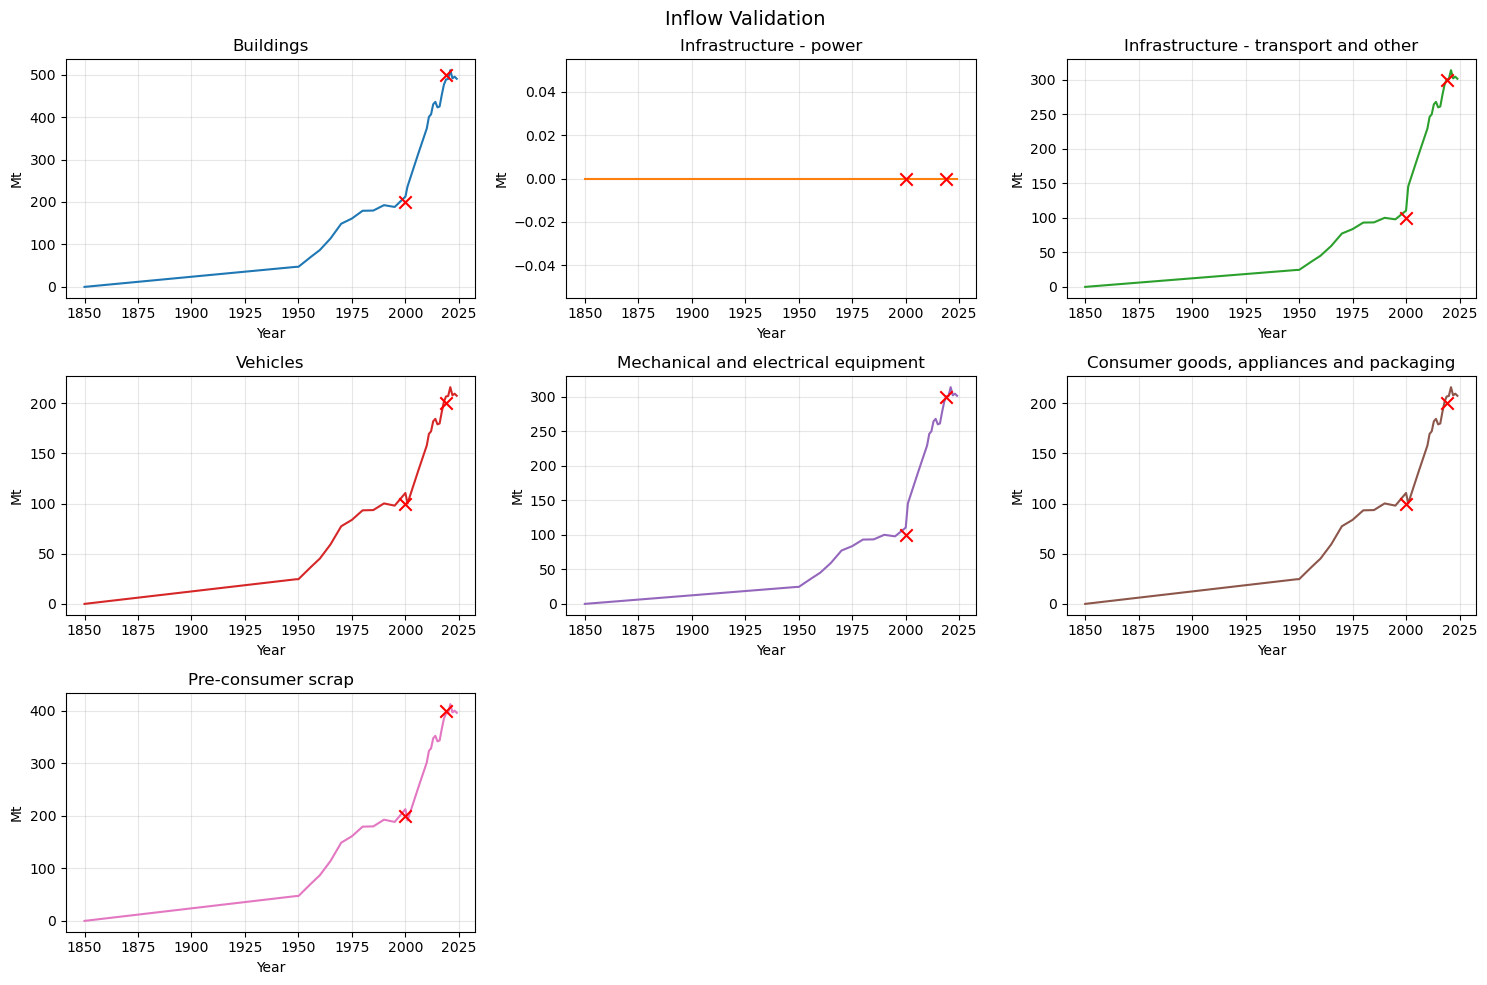

In [247]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cat in enumerate(shares_2000.keys()):
    ax = axes[i]
    col = f"inflow_ssp1_{cat.lower()}"
    if col in results_ssp1.columns:
        ax.plot(results_ssp1["Year"], results_ssp1[col], color=colors[i])
    if cat in validation_2000:
        ax.scatter(2000, validation_2000[cat], color="red", zorder=5, s=80, marker='x')
    if cat in validation_2019:
        ax.scatter(2019, validation_2019[cat], color="red", zorder=5, s=80, marker='x')
    ax.set_title(cat)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mt")
    ax.grid(True, alpha=0.3)

# Hide the 2 empty subplots (3x3 grid has 9 slots, only 7 used)
for j in range(len(shares_2000), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Inflow Validation", fontsize=14)
plt.tight_layout()
plt.show()

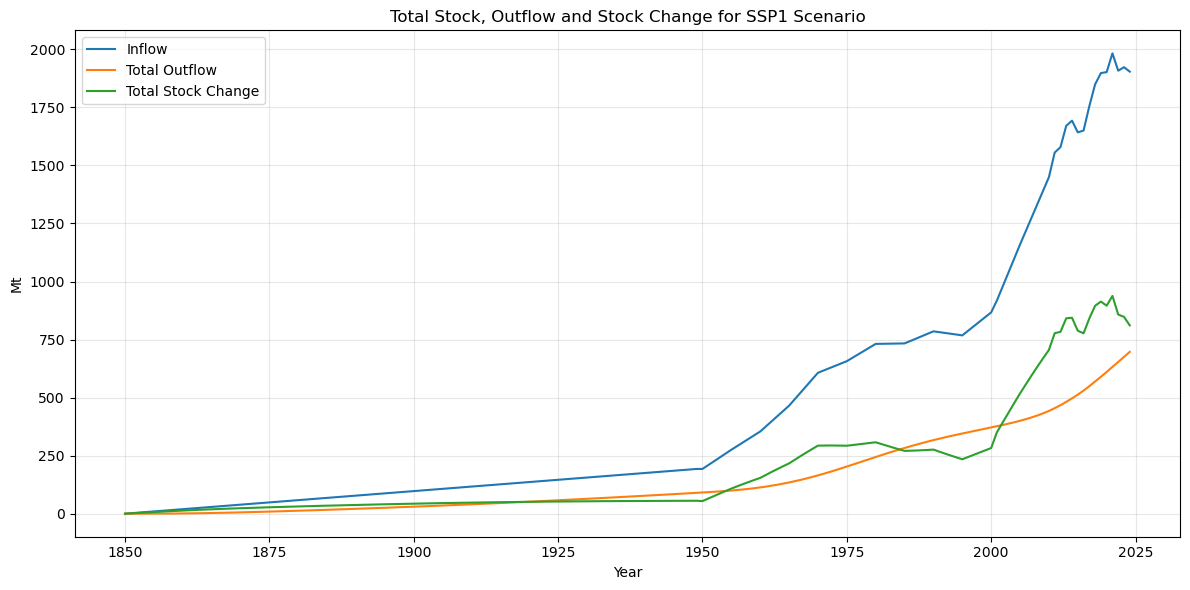

In [269]:
# Plot the total results for stock, outflow and stock change
plt.figure(figsize=(12, 6))
plt.plot(results_ssp1["Year"], results_ssp1["inflow_ssp1_total"], label="Inflow")
#plt.plot(results_ssp1["Year"], results_ssp1["stock_ssp1_total"], label="Total Stock")
plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_total"], label="Total Outflow")
plt.plot(results_ssp1["Year"], results_ssp1["stock_change_ssp1_total"], label="Total Stock Change")
plt.xlabel("Year")
plt.ylabel("Mt")
plt.title("Total Stock, Outflow and Stock Change for SSP1 Scenario")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

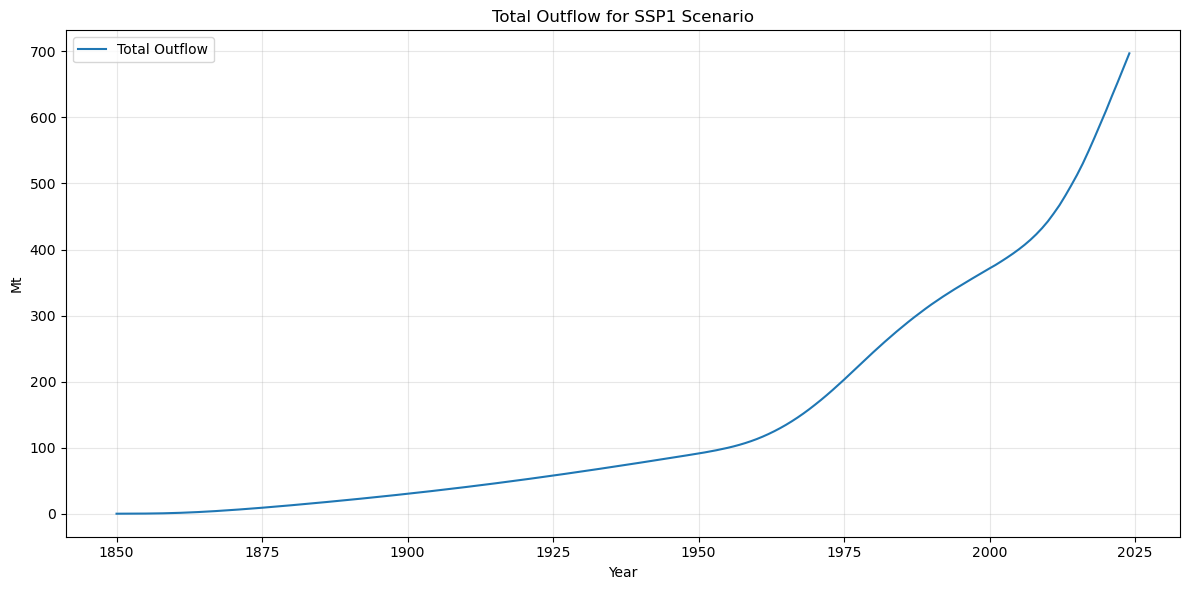

In [264]:
# Plot the total results for outflow
plt.figure(figsize=(12, 6))
plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_total"], label="Total Outflow")
plt.xlabel("Year")
plt.ylabel("Mt")
plt.title("Total Outflow for SSP1 Scenario")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

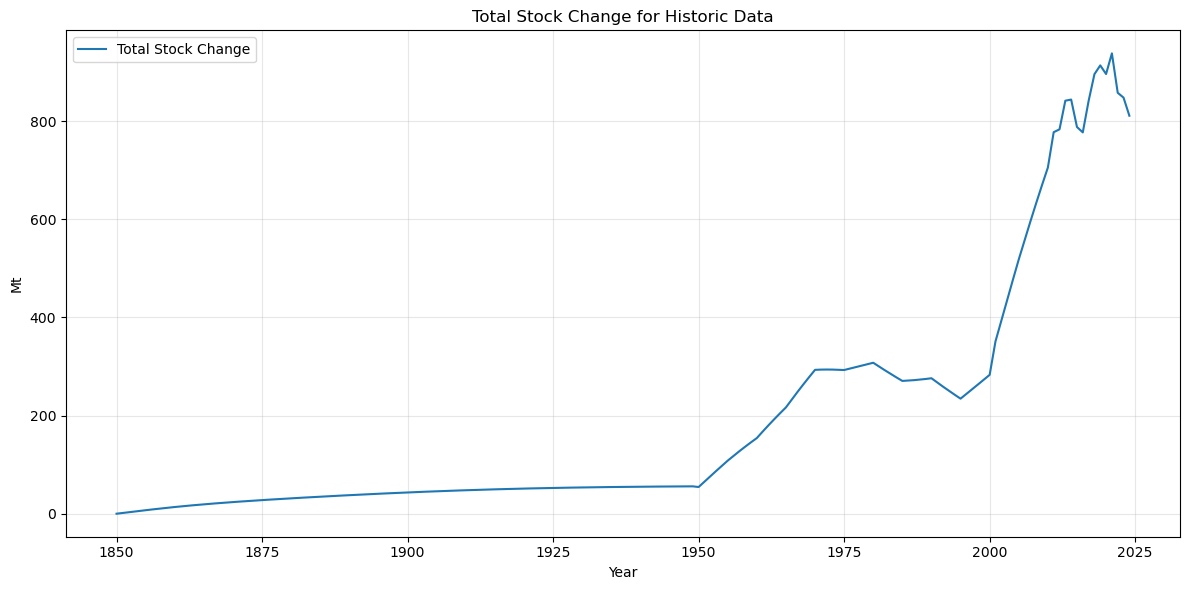

In [265]:
# Plot the total results for  stock change
plt.figure(figsize=(12, 6))
plt.plot(results_ssp1["Year"], results_ssp1["stock_change_ssp1_total"], label="Total Stock Change")
plt.xlabel("Year")
plt.ylabel("Mt")
plt.title("Total Stock Change for Historic Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

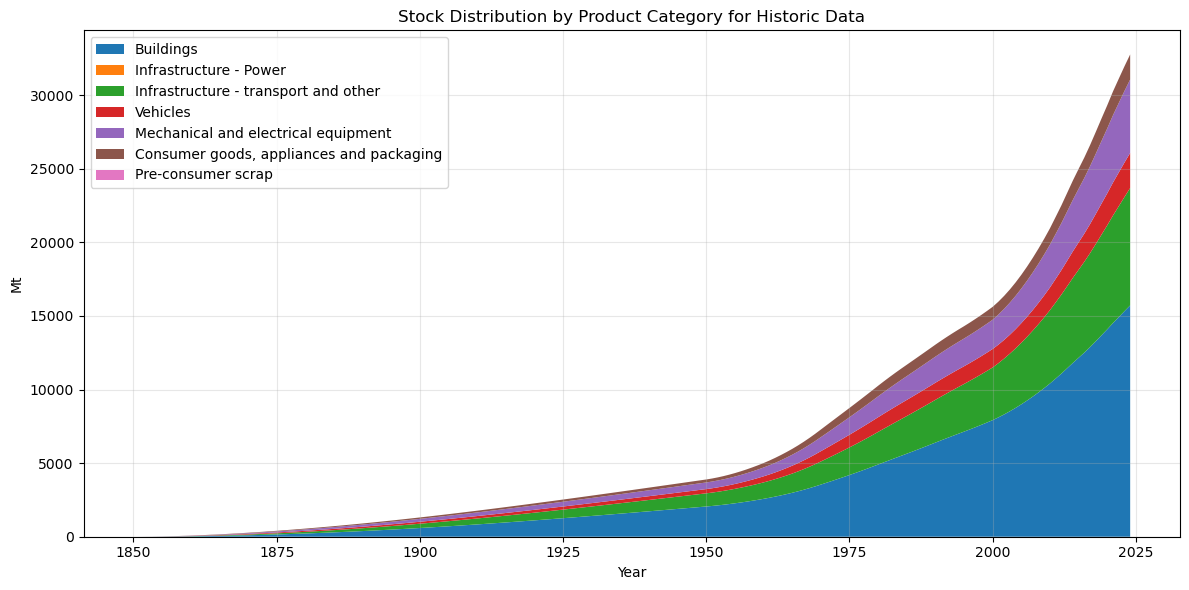

In [266]:
# Plot the results per product category for stock as stacked area plot
plt.figure(figsize=(12, 6))
plt.stackplot(results_ssp1["Year"], 
              results_ssp1["stock_ssp1_buildings"], 
              results_ssp1["stock_ssp1_infrastructure - power"],
              results_ssp1["stock_ssp1_infrastructure - transport and other"],
              results_ssp1["stock_ssp1_vehicles"],
              results_ssp1["stock_ssp1_mechanical and electrical equipment"],
              results_ssp1["stock_ssp1_consumer goods, appliances and packaging"],
              results_ssp1["stock_ssp1_pre-consumer scrap"], 
                labels=["Buildings", "Infrastructure - Power", "Infrastructure - transport and other", "Vehicles", "Mechanical and electrical equipment", "Consumer goods, appliances and packaging", "Pre-consumer scrap"],
                colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'])
plt.xlabel("Year")
plt.ylabel("Mt")
plt.title("Stock Distribution by Product Category for Historic Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

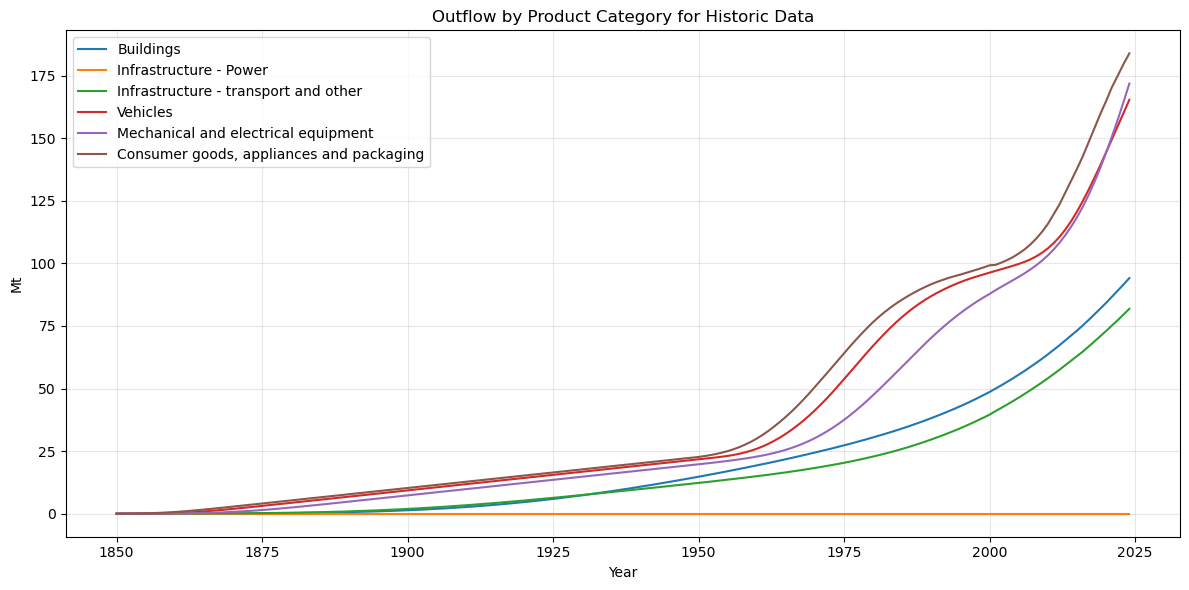

In [267]:
# Plot the results per product category for outflow, not stacked
plt.figure(figsize=(12, 6))
plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_buildings"], label="Buildings")
plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_infrastructure - power"], label="Infrastructure - Power")
plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_infrastructure - transport and other"], label="Infrastructure - transport and other")
plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_vehicles"], label="Vehicles")
plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_mechanical and electrical equipment"], label="Mechanical and electrical equipment")
plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_consumer goods, appliances and packaging"], label="Consumer goods, appliances and packaging")
#plt.plot(results_ssp1["Year"], results_ssp1["outflow_ssp1_pre-consumer scrap"], label="Pre-consumer scrap")
plt.xlabel("Year")
plt.ylabel("Mt")
plt.title("Outflow by Product Category for Historic Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()